In [4]:
import firebase_admin
from firebase_admin import credentials, storage

# Reinitialize if needed
if not firebase_admin._apps:
    cred = credentials.Certificate('firebase_service_account.json')
    firebase_admin.initialize_app(cred, {
    'storageBucket': 'ai-fashion-app-e61ed.firebasestorage.app'
})


# Try accessing the bucket
try:
    bucket = storage.bucket('ai-fashion-app-e61ed.firebasestorage.app')
    print(f"✅ Bucket name: {bucket.name}")

    # Try listing files in root (empty list is okay)
    blobs = list(bucket.list_blobs())
    print(f"✅ Bucket is accessible. Files found: {len(blobs)}")

except Exception as e:
    print(f"❌ Error accessing bucket: {e}")


✅ Bucket name: ai-fashion-app-e61ed.firebasestorage.app
✅ Bucket is accessible. Files found: 18


## Search from Item Inventory

running qdrant locally/docker

```docker run -p 6333:6333 -p 6334:6334 -v qdrant_data:/qdrant/storage qdrant/qdrant```


In [2]:
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
import numpy as np
from qdrant_client.models import Filter, FieldCondition, MatchValue
import uuid

# --- Step 1: Initialize model and Qdrant client ---
model = SentenceTransformer('all-MiniLM-L6-v2')
qdrant = QdrantClient(":memory:")  # or "http://localhost:6333" for persistent server

collection_name = "closet_vectors"
dimension = 384  # dimension

# --- Step 2: Create collection ---
qdrant.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=dimension, distance=Distance.COSINE)
)

# --- Step 3: Closet Items and Embedding ---
closet_items = [
    # FORMAL / PROFESSIONAL
    {
        "id": "1",
        "name": "Black Wrap Dress",
        "description": "A black wrap dress suitable for formal events.",
        "category": "dress",
        "style": "formal",
        "season": "Autumn",
        "color": "black"
    },
    {
        "id": "2",
        "name": "White Linen Shirt",
        "description": "Lightweight white shirt, business casual.",
        "category": "tops",
        "style": "business casual",
        "season": "Summer",
        "color": "white"
    },
    {
        "id": "3",
        "name": "Black Trousers",
        "description": "Formal black trousers for professional events.",
        "category": "bottoms",
        "style": "professional",
        "season": "Autumn",
        "color": "black"
    },
    {
        "id": "4",
        "name": "Black Leather Loafers",
        "description": "Polished black loafers, ideal for formal settings.",
        "category": "shoes",
        "style": "formal",
        "season": "Autumn",
        "color": "black"
    },
    {
        "id": "5",
        "name": "Silver Stud Earrings",
        "description": "Minimalist silver earrings for understated elegance.",
        "category": "jewelry",
        "style": "formal",
        "season": "All",
        "color": "silver"
    },
    {
        "id": "6",
        "name": "Structured Black Tote",
        "description": "A structured black tote bag suitable for professional use.",
        "category": "bags",
        "style": "professional",
        "season": "Autumn",
        "color": "black"
    },
    # SMART CASUAL
    {
        "id": "7",
        "name": "Beige Cropped Blazer",
        "description": "A light cropped blazer that adds polish to any casual outfit.",
        "category": "outerwear",
        "style": "smart casual",
        "season": "Spring",
        "color": "beige"
    },
    {
        "id": "8",
        "name": "Blue Wide-Leg Jeans",
        "description": "High-waisted wide-leg jeans for casual or smart-casual wear.",
        "category": "bottoms",
        "style": "casual",
        "season": "Spring",
        "color": "blue"
    },
    {
        "id": "9",
        "name": "Striped Cotton Tee",
        "description": "A breathable cotton tee for everyday wear.",
        "category": "tops",
        "style": "casual",
        "season": "Summer",
        "color": "white"
    },
    {
        "id": "10",
        "name": "Canvas Tote Bag",
        "description": "A simple canvas bag for everyday errands.",
        "category": "bags",
        "style": "casual",
        "season": "All",
        "color": "cream"
    },
    {
        "id": "11",
        "name": "White Sneakers",
        "description": "Low-top sneakers great for walking and everyday looks.",
        "category": "shoes",
        "style": "casual",
        "season": "Spring",
        "color": "white"
    },
    # PARTY / COCKTAIL
    {
        "id": "12",
        "name": "Red Satin Slip Dress",
        "description": "A bold red dress perfect for cocktail or evening parties.",
        "category": "dress",
        "style": "cocktail",
        "season": "Summer",
        "color": "red"
    },
    {
        "id": "13",
        "name": "Gold Clutch",
        "description": "A shiny gold clutch for dressy occasions.",
        "category": "bags",
        "style": "night-time party",
        "season": "Summer",
        "color": "gold"
    },
    {
        "id": "14",
        "name": "Strappy Gold Heels",
        "description": "Heels that add elegance to evening looks.",
        "category": "shoes",
        "style": "cocktail",
        "season": "Summer",
        "color": "gold"
    },
    {
        "id": "15",
        "name": "Dangling Crystal Earrings",
        "description": "Sparkly earrings to finish a glam look.",
        "category": "jewelry",
        "style": "night-time party",
        "season": "All",
        "color": "silver"
    }
]


# Embed and upload items to Qdrant
for item in closet_items:
    embedding = model.encode(item['description']).tolist()
    qdrant.upsert(
        collection_name=collection_name,
        points=[PointStruct(
            id=int(item["id"]),
            vector=embedding,
            payload=item
        )]
    )

# --- Step 4: Query vector from user input ---
user_query = "party night out with friends"
query_vector = model.encode(user_query).tolist()

# --- Step 5: Vector search ---
results = qdrant.search(
    collection_name=collection_name,
    query_vector=query_vector,
    limit=5
)

# --- Step 6: Group results by category for LLM prompt ---
# grouped_items = {}
# for hit in results:
#     item = hit.payload
#     cat = item["category"]
#     if cat not in grouped_items:
#         grouped_items[cat] = []
#     grouped_items[cat].append(item["name"])
categories = ["tops", "bottoms", "dress", "shoes", "bags", "jewelry", "outerwear"]

grouped_items = defaultdict(list)

# Loop through each category and get 3 closest items per category
for cat in categories:
    query_filter = Filter(
        must=[
            FieldCondition(
                key="category",
                match=MatchValue(value=cat)
            )
        ]
    )
    
    results = qdrant.search(
        collection_name=collection_name,
        query_vector=query_vector,
        limit=5,
        query_filter=query_filter
    )
    
    for hit in results[:3]:
        item = hit.payload
        entry = f"{item['name']} (ID:{hit.id}): {item['description']}"
        grouped_items[cat].append(entry)

# --- Step 7: Output ---
print(f"🔍 Closest Items for Query: '{user_query}'")
for category, items in grouped_items.items():
    print(f"\n🧺 {category.upper()}:")
    for item in items:
        print("  -", item)


/Users/phonavitra/Desktop/Summer Project 2025/Project 1 AIFashionCompanionApp/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/8d/gp5c13l962z3c391pmyp2bkm0000gn/T/ipykernel_10112/3011693900.py:17: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant.recreate_collection(


🔍 Closest Items for Query: 'party night out with friends'

🧺 TOPS:
  - White Linen Shirt (ID:2): Lightweight white shirt, business casual.
  - Striped Cotton Tee (ID:9): A breathable cotton tee for everyday wear.

🧺 BOTTOMS:
  - Black Trousers (ID:3): Formal black trousers for professional events.
  - Blue Wide-Leg Jeans (ID:8): High-waisted wide-leg jeans for casual or smart-casual wear.

🧺 DRESS:
  - Red Satin Slip Dress (ID:12): A bold red dress perfect for cocktail or evening parties.
  - Black Wrap Dress (ID:1): A black wrap dress suitable for formal events.

🧺 SHOES:
  - Strappy Gold Heels (ID:14): Heels that add elegance to evening looks.
  - Black Leather Loafers (ID:4): Polished black loafers, ideal for formal settings.
  - White Sneakers (ID:11): Low-top sneakers great for walking and everyday looks.

🧺 BAGS:
  - Canvas Tote Bag (ID:10): A simple canvas bag for everyday errands.
  - Structured Black Tote (ID:6): A structured black tote bag suitable for professional use.
  - G

/var/folders/8d/gp5c13l962z3c391pmyp2bkm0000gn/T/ipykernel_10112/3011693900.py:182: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = qdrant.search(
/var/folders/8d/gp5c13l962z3c391pmyp2bkm0000gn/T/ipykernel_10112/3011693900.py:211: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = qdrant.search(


In [3]:
import json
import ollama

# User input"
user_intent = "party night out with friends"
weather = "18°C, cloudy"

# Reuse grouped_items from Qdrant results
# Example: grouped_items = {'dress': [...], 'shoes': [...], ...}

# Convert grouped items to text for prompt
item_text = ""
for category, items in grouped_items.items():
    item_text += f"\n{category.upper()}:\n"
    for item in items:
        item_text += f"  - {item}\n"

# Final prompt to send to LLM
prompt = f"""
You are a fashion stylist. Based on the user’s closet and request, create 2 complete outfits that follow these structure rules:

1. Template A: TOP + BOTTOM + SHOES + BAG + JEWELRY [+OUTERWEAR]
2. Template B: DRESS/OVERALL + SHOES + BAG + JEWELRY [+OUTERWEAR]

The occasion is: {user_intent}  
Weather is: {weather}

Choose items from the closet below. Use each item only once. Use only items that match the occasion and weather. If an item is not suitable, skip it.

Closet Items:
{item_text}

Return your response in the following JSON format:
[
  {{
    "look_name": "...",
    "template": "Template A or B",
    "description": "...",
    "items": [
      {{
        "name": "item name 1",
        "id": "item_id_1",
        "description": "item description 1"
      }},
      {{
        "name": "item name 2",
        "id": "item_id_2",
        "description": "item description 2"
      }}
    ]
  }}
]
"""

response = ollama.chat(
    model='gemma3n:latest',  # or 'mistral'
    messages=[
        {"role": "system", "content": "You are a fashion stylist."},
        {"role": "user", "content": prompt}
    ]
)

print(response['message']['content'])

```json
[
  {
    "look_name": "Glam Party Night",
    "template": "Template A",
    "description": "A chic and sophisticated party look. The red satin slip dress is the focal point, elevated with gold heels and a clutch. The cropped blazer adds a touch of polish for a night out with friends. Dangling crystal earrings complete the glamorous vibe.",
    "items": [
      {
        "name": "Red Satin Slip Dress",
        "id": "12",
        "description": "A bold red dress perfect for cocktail or evening parties."
      },
      {
        "name": "Strappy Gold Heels",
        "id": "14",
        "description": "Heels that add elegance to evening looks."
      },
      {
        "name": "Gold Clutch",
        "id": "13",
        "description": "A shiny gold clutch for dressy occasions."
      },
      {
        "name": "Dangling Crystal Earrings",
        "id": "15",
        "description": "Sparkly earrings to finish a glam look."
      },
      {
        "name": "Beige Cropped Blazer",
  

## Classification


"""
'brand': 'Gucci',
'name': 'Mock Blazer',
'description': 'A stylish black blazer suitable for business casual wear.',
'category': 'Outerwear',
'color': 'Black',
'style': 'Business Casual',
'season': 'Autumn',
"""

In [5]:
metadata= {
'brand': 'Gucci',
'name': 'Mock Blazer',
'description': 'A stylish black blazer suitable for business casual wear.',
'category': 'Outerwear',
'color': 'Black',
'style': 'Business Casual',
'season': 'Autumn',
}

### Trying RAG from Text description for chatbot from Qdrant

In [3]:
info = qdrant.get_collection(collection_name="closet_vectors")
print(info.vectors_count)
print(info.config.params.vectors)

None
size=512 distance=<Distance.COSINE: 'Cosine'> hnsw_config=None quantization_config=None on_disk=None datatype=None multivector_config=None


In [13]:
from collections import defaultdict
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue
from sentence_transformers import SentenceTransformer
import numpy as np

# --- Step 1: Initialize SentenceTransformer model and Qdrant client ---
model_name = "sentence-transformers/clip-ViT-B-32"
clip_model = SentenceTransformer(model_name)

qdrant = QdrantClient(host="localhost", port=6333)
collection_name = "closet_vectors"

# --- Step 2: Encoding function ---
def encode_text(text):
    return clip_model.encode(text, convert_to_numpy=True).tolist()

# --- Step 3: User query embedding ---
user_query = "exercise outfit"
query_vector = encode_text(user_query)

# --- Step 4: Fashion categories ---
categories = ["tops", "bottoms", "dress", "shoes", "bags", "jewelry", "outerwear"]
grouped_items = defaultdict(list)

# --- Step 5: Search Qdrant (filter by type='text' and category=...) ---
for cat in categories:
    query_filter = Filter(
        must=[
            FieldCondition(key="type", match=MatchValue(value="text")),
            FieldCondition(key="category", match=MatchValue(value=cat))
        ]
    )

    results = qdrant.search(
        collection_name=collection_name,
        query_vector=query_vector,
        limit=5,
        query_filter=query_filter,
        with_payload=True
    )

    for hit in results[:3]:
        item = hit.payload
        entry = f"(ID:{hit.id}): {item['description']}"
        grouped_items[cat].append(entry)

# --- Step 6: Output ---
print(f"🔍 Closest Items for Query: '{user_query}'")
for category, items in grouped_items.items():
    print(f"\n🧺 {category.upper()}:")
    for item in items:
        print("  -", item)


🔍 Closest Items for Query: 'exercise outfit'

🧺 TOPS:
  - (ID:4b7f88d4-4791-49ac-8449-a3b6d1d83aa6): Elevate your spring wardrobe with this classic White Shirt. Part of our versatile Tops collection, this shirt is designed with a business casual style, perfect for meetings, office days, or adding a refined touch to your weekend look. Ideal for spring layering and warm weather, it’s a must-have staple.
  - (ID:3a4f284a-f156-4dfd-be5b-44c7a1425d77): Embrace effortless style with our White Casual Top. This classic white top is perfect for warm spring days. Its relaxed, casual style makes it ideal for brunch with friends, a relaxed day out, or layering for a comfortable everyday look.
  - (ID:6aaf33d2-5847-413d-86b8-bbdf083da48f): Elevate your summer style with our Red Athleisure T-shirt. This vibrant red tee is perfect for hitting the gym, running errands, or lounging around town. Its comfortable, sporty design makes it ideal for warm weather and any casual occasion.

🧺 BOTTOMS:
  - (ID:7

/var/folders/8d/gp5c13l962z3c391pmyp2bkm0000gn/T/ipykernel_47127/3370791194.py:35: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = qdrant.search(


In [ ]:
import json
import ollama

# Convert grouped items to text for prompt
item_text = ""
for category, items in grouped_items.items():
    item_text += f"\n{category.upper()}:\n"
    for item in items:
        item_text += f"  - {item}\n"

# Final prompt to send to LLM
prompt = f"""
You are a fashion stylist. Based on the user’s closet and request, create 2 complete outfits that follow these structure rules:

1. Template A: TOP + BOTTOM + SHOES + BAG + JEWELRY [+OUTERWEAR]
2. Template B: DRESS/OVERALL + SHOES + BAG + JEWELRY [+OUTERWEAR]

The occasion is: {user_query}  

Choose items from the closet below. Use each item only once. Use only items that match the occasion and weather. If an item is not suitable, skip it.
Try to include both templates if possible. If a DRESS or OVERALL is not available, just provide outfits using Template A.
When you choose a dress or overall, you can skip the top and bottom items.


Closet Items:
{item_text}

Return your response in the following JSON format:
[
  {{
    "look_name": "...",
    "template": "Template A or B",
    "description": "...",
    "items": [
      {{
        "name": "item name 1",
        "id": "item_id_1",
        "category" : "top"
        "description": "item description 1"
      }},
      {{
        "name": "item name 2",
        "id": "item_id_2",
        "category" : "bottom"
        "description": "item description 2"
      }}
    ]
  }}
]
"""

response = ollama.chat(
    model='gemma3:4b',  # or 'mistral'
    messages=[
        {"role": "system", "content": "You are a fashion stylist."},
        {"role": "user", "content": prompt}
    ]
)

result = response['message']['content']

In [63]:
def parse_llm_json_block(raw_text: str):
    if raw_text.startswith("```json"):
        raw_text = raw_text.removeprefix("```json")
    if raw_text.endswith("```"):
        raw_text = raw_text.removesuffix("```")
    return json.loads(raw_text.strip())

looks_json = parse_llm_json_block(result)
print (looks_json)

[{'look_name': 'Gym Ready Cool', 'template': 'Template A', 'description': 'A comfortable and sporty outfit perfect for a workout or casual day.', 'items': [{'name': 'Red Athleisure T-shirt', 'id': '6aaf33d2-5847-413d-86b8-bbdf083da48f', 'category': 'top', 'description': 'A vibrant red tee perfect for hitting the gym.'}, {'name': 'Black Cargo Pants', 'id': 'a95b3875-206d-4912-9af6-912ca28e5e51', 'category': 'bottom', 'description': 'Athleisure cargo pants for a sporty edge.'}, {'name': 'Bulk White Casual Shoes', 'id': 'c5a71694-ad34-4e18-9434-169c936c514d', 'category': 'shoes', 'description': 'Clean, white shoes for a relaxed fit.'}, {'name': 'Pink Professional Handbag', 'id': '5e486f56-3657-4dad-a814-8aeee62247f5', 'category': 'bag', 'description': 'A stylish pink bag for a pop of color.'}]}, {'look_name': 'Comfortable Workout', 'template': 'Template B', 'description': 'A simple and comfortable dress outfit for a relaxed workout or day out.', 'items': [{'name': 'White Flower Dress', 'i

In [18]:
import firebase_admin
from firebase_admin import credentials, firestore
from firebase_admin import storage
if not firebase_admin._apps:
    cred = credentials.Certificate("firebase_service_account.json")
    firebase_admin.initialize_app(cred, {
        'storageBucket': 'ai-fashion-app-e61ed.appspot.com'
    })

db= firestore.client()
bucket = storage.bucket()

In [42]:
from PIL import Image
from io import BytesIO

def get_item_data_by_vector_id(uid, vector_id_text):
    vector_id_text = vector_id_text.replace("-", "")  # Normalize to match Firestore format
    collection = db.collection("users").document(uid).collection("clothing_items")
    docs = collection.where("vector_id_text", "==", vector_id_text).stream()
    for doc in docs:
        data = doc.to_dict()
        return {
            "image_url": data["image_url"],
            "firestore_id": doc.id
        }
    return None


def download_image_from_storage(image_url):
    try:
        print("📥 Downloading image from:", image_url)
        response = requests.get(image_url)
        response.raise_for_status()  # Raises an error if the request fails
        return Image.open(BytesIO(response.content)).convert("RGB")
    except requests.RequestException as e:
        print("❌ Failed to download image:", e)
        return None


In [56]:
from PIL import Image, ImageDraw

TEMPLATE_LAYOUTS = {
    "Template A": {
        "top": (0, 0), "outerwear": (1, 0), "jewelry": (2, 0),
        "bottom": (0, 1), "shoes": (1, 1), "accessories": (2, 1),
        "bag": (2, 2)
    },
    "Template B": {
        "dress": (0, 0), "outerwear": (1, 0), "jewelry": (2, 0),
        "shoes": (1, 1), "accessories": (2, 1), "bag": (2, 2)
    }
}



from IPython.display import display

def show_look_collage(look, uid):
    category_to_image = {}
    item_ids = []

    for item in look["items"]:
        item_data = get_item_data_by_vector_id(uid, item["id"])
        if not item_data:
            print(f"❌ Not found: {item['id']} ({item['name']})")
            continue

        img = download_image_from_storage(item_data["image_url"])
        if img:
            category = item.get("category", "").lower()
            category_to_image[category] = img
            item_ids.append(item_data["firestore_id"])
        else:
            print(f"⚠️ Could not load image for: {item['name']}")

    collage = create_template_collage(look["template"], category_to_image)
    display(collage)
    print("🧾 Firestore IDs:", item_ids)




In [59]:
def create_compact_collage(category_to_image, cell_size=200, padding=20, bg_color=(255, 255, 255), max_cols=3):
    from math import ceil

    categories = list(category_to_image.keys())
    count = len(categories)
    cols = min(count, max_cols)
    rows = ceil(count / cols)

    width = cols * (cell_size + padding) + padding
    height = rows * (cell_size + padding) + padding
    collage = Image.new("RGB", (width, height), bg_color)

    draw = ImageDraw.Draw(collage)

    for row in range(rows):
        start_idx = row * cols
        end_idx = min(start_idx + cols, count)
        row_categories = categories[start_idx:end_idx]
        row_count = len(row_categories)

        # Calculate total row width for centering
        row_width = row_count * (cell_size + padding) - padding
        x_start = (width - row_width) // 2

        for i, category in enumerate(row_categories):
            x = x_start + i * (cell_size + padding)
            y = padding + row * (cell_size + padding)

            img = category_to_image[category].resize((cell_size, cell_size))
            collage.paste(img, (x, y))

            # Optional: category label
            draw.text((x + 5, y + 5), category.title(), fill=(0, 0, 0))

    return collage



🎨 Look: Gym Ready Cool
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752733917861.jpg?alt=media&token=291252be-65ae-4f78-b84d-514e0275c840


/Users/phonavitra/Desktop/Summer Project 2025/Project 1 AIFashionCompanionApp/fashion_backend/venv/lib/python3.13/site-packages/google/cloud/firestore_v1/base_collection.py:304: UserWarning: Detected filter using positional arguments. Prefer using the 'filter' keyword argument instead.
  return query.where(field_path, op_string, value)


📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752734219681.jpg?alt=media&token=91316b8e-55b5-49a0-88c4-4370032d52e6
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752734687531.jpg?alt=media&token=1471b6e8-94ec-46e7-bd76-773a862e67b6
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752735032234.jpg?alt=media&token=1a6b75b8-df06-45e8-b0f0-736a67dd6e92


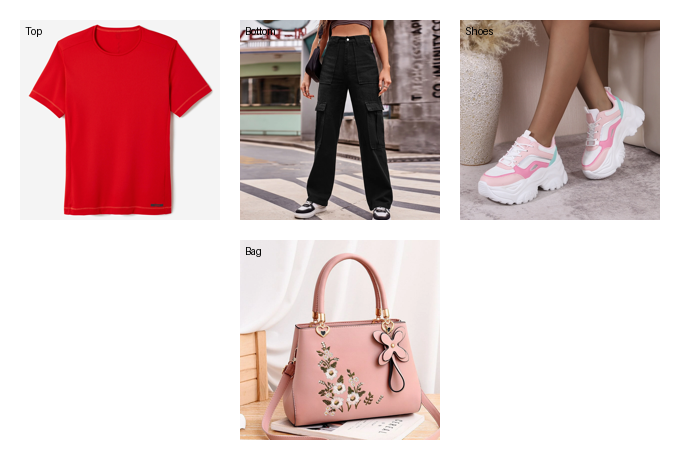

🧾 Firestore Item IDs in Collage: ['37', '40', '47', '50']

🎨 Look: Comfortable Workout
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752734424888.jpg?alt=media&token=abc23037-ca25-4ed2-906f-ba9a771fa262
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752734687531.jpg?alt=media&token=1471b6e8-94ec-46e7-bd76-773a862e67b6
📥 Downloading image from: https://firebasestorage.googleapis.com/v0/b/ai-fashion-app-e61ed.firebasestorage.app/o/clothes%2F1752735032234.jpg?alt=media&token=1a6b75b8-df06-45e8-b0f0-736a67dd6e92


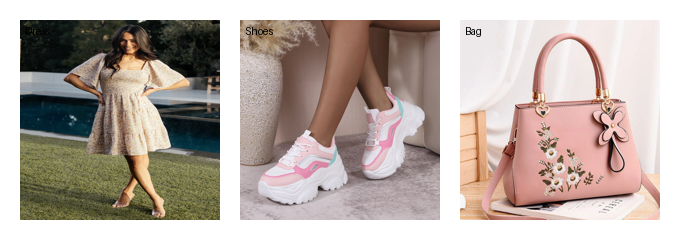

🧾 Firestore Item IDs in Collage: ['43', '47', '50']


In [64]:
import json
import urllib.parse
import requests
from PIL import Image
from io import BytesIO

uid = "59z3c0lXufQfc9ldqYtY5NZLQPr2" 

from IPython.display import display

# look = looks_json[0]  # or loop through all looks

for look in looks_json:
    print(f"\n🎨 Look: {look['look_name']}")
    template = look["template"]

    category_to_image = {}
    item_firestore_ids = []

    for item in look["items"]:
        item_data = get_item_data_by_vector_id(uid, item["id"])
        if not item_data:
            print(f"❌ Item not found for ID: {item['id']} ({item['name']})")
            continue

        img = download_image_from_storage(item_data["image_url"])
        if img:
            category = item.get("category", "").lower()
            category_to_image[category] = img
            item_firestore_ids.append(item_data["firestore_id"])
        else:
            print(f"⚠️ Failed to load image for item {item['id']}")

    if category_to_image:
        collage = create_compact_collage(category_to_image)
        display(collage)
        print("🧾 Firestore Item IDs in Collage:", item_firestore_ids)
    else:
        print("⚠️ No images to display for this look.")


### Making Description

In [9]:
import ollama
prompt = f"""
Using the following fashion item metadata, write a short product description that includes all the details: name, category, color, style, and season.

- Name: {metadata['name']}
- Category: {metadata['category']}
- Color: {metadata['color']}
- Style: {metadata['style']}
- Season: {metadata['season']}

Ensure that all fields are reflected clearly in the description and use neutral language.

Return only the description text without any additional formatting or JSON structure.
"""

response = ollama.chat(
    model='gemma3:4b',
    messages=[
        {"role": "system", "content": "You are a fashion product description generator."},
        {"role": "user", "content": prompt.strip()}
    ]
)

print("Generated Description:")
description = response['message']['content'].strip()
print(description)

lines = [line.strip() for line in description.splitlines() if line.strip()]

# Get the last non-empty line
clean_description = lines[-1]

print("Cleaned Description:")
print(clean_description)


Generated Description:
This sleek black Mock Blazer is a versatile addition to your autumn wardrobe. Part of our outerwear collection, this business casual style offers a sophisticated look perfect for layering during the cooler months.
Cleaned Description:
This sleek black Mock Blazer is a versatile addition to your autumn wardrobe. Part of our outerwear collection, this business casual style offers a sophisticated look perfect for layering during the cooler months.


### Exposed API from remote server

- **Get local IP network**

    _bash_
    ```  
    ifconfig | grep inet 
    ```

- **Host Ollama in Linux/docker.. right now I am js hosting on MacOS**
    
    _bash_
    ```
    OLLAMA_HOST=0.0.0.0 ollama serve
    ```


In [45]:
import requests

response = requests.post(
    "http://192.168.0.116:11434/api/chat",
    json={
        "model": "gemma3n",
        "messages": [{"role": "user", "content": "Hello from LAN!"}]
    },
    stream=True
)

full_reply = ""
for line in response.iter_lines():
    if line:
        chunk = line.decode("utf-8")
        try:
            content = json.loads(chunk).get("message", {}).get("content", "")
            full_reply += content
        except Exception:
            pass

print("Assistant:", full_reply.strip())


Assistant: Hello from the digital world! 👋 

It's great to hear from you from LAN!  Is there anything I can help you with today?  Let me know what's on your mind. 😊 

(Just a little friendly acknowledgement of your location!)


## Similarity Search From Image

https://docs.autodistill.com/utilities/use-embeddings-in-classification/#embeddingontologyraw-example

In [1]:
import torch
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt


/Users/phonavitra/Desktop/Summer Project 2025/Project 1 AIFashionCompanionApp/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def encode_image_with_clip(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
    return outputs[0].numpy(), image


ValueError: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434